In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [9]:
#Understanding my dataset columns
tips = sb.load_dataset('tips')
print(tips.head())
print(f"dataset shape: {tips.shape}")
print(tips.tail())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
dataset shape: (244, 7)
     total_bill   tip     sex smoker   day    time  size
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2


In [10]:
#info on the dataset
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [11]:
#description on the dataset
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Insights from Statistics:
### Total Bili:
Average: 19.79-Range: 3.07 to 50.81 Most bills are between 13 and $24 (IQR)

### Tip:
Average: 2.99-Range:1.00 to 10.00-Most tips are between2 and $3.56 (IQR)

### Party Size:
1. Average: 2.57 people
2. Range: 1 to 6 people
3. Most parties are 2 people

In [15]:
##Check the datatypes
tips.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [27]:
## Checking for duplicates
duplicates = tips.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate Rows")
    #This keep=false will make sure the duplicate entries are returned, not the distinct one alone.
    print(tips[tips.duplicated(keep=False)])


Total duplicate rows: 1

Duplicate Rows
     total_bill  tip     sex smoker   day   time  size
198        13.0  2.0  Female    Yes  Thur  Lunch     2
202        13.0  2.0  Female    Yes  Thur  Lunch     2


In [33]:
columns = tips.columns.to_list()
columns
filteredCol = ['sex', 'smoker', 'day', 'time']
for col in filteredCol:
    print(f"\nUnique values of {col}: {tips[col].unique()}")
    print(f"\nCount of Unique values of {col}: {tips[col].nunique()}")




Unique values of sex: ['Female', 'Male']
Categories (2, str): ['Male', 'Female']

Count of Unique values of sex: 2

Unique values of smoker: ['No', 'Yes']
Categories (2, str): ['Yes', 'No']

Count of Unique values of smoker: 2

Unique values of day: ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']

Count of Unique values of day: 4

Unique values of time: ['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner']

Count of Unique values of time: 2


## Range of total bill in my Data

Text(0.5, 1.0, 'Range of Total bill w.r.t days')

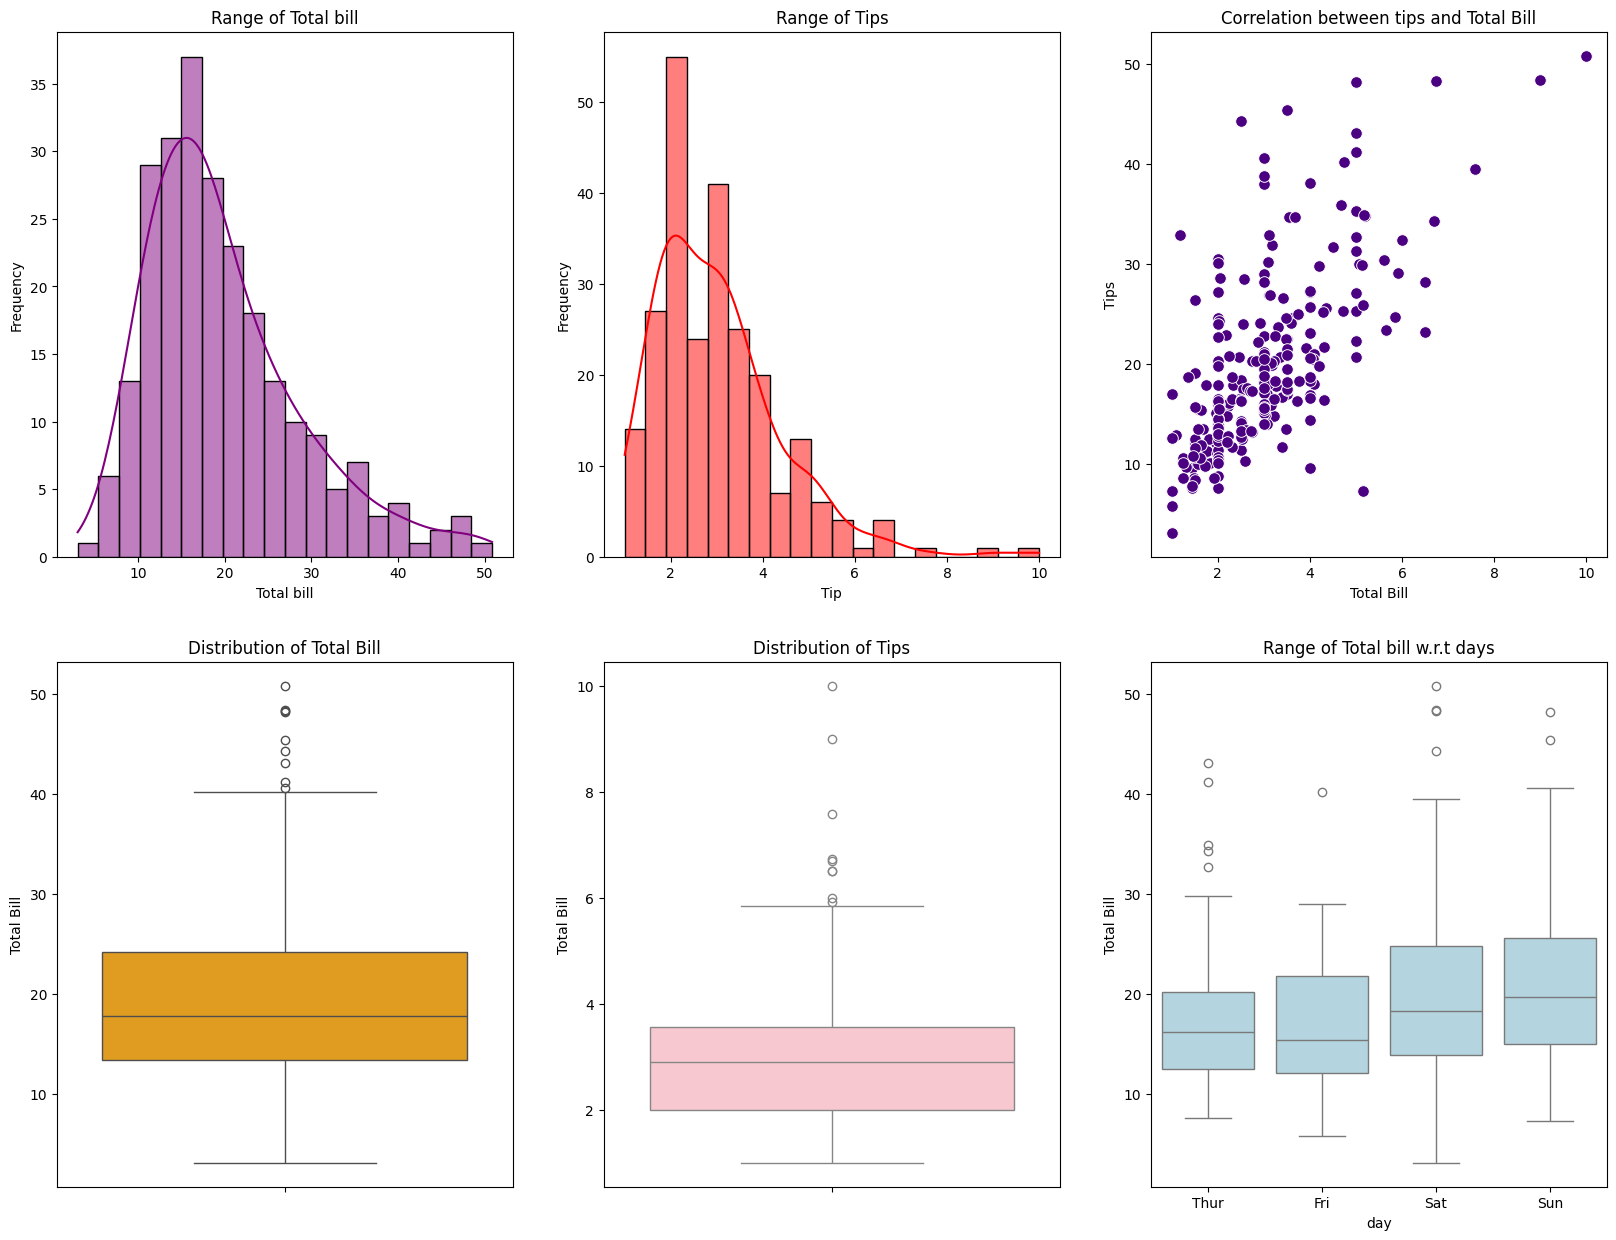

In [123]:
fig,ax=plt.subplots(2,3,figsize=(20,15))
sb.histplot(tips['total_bill'],kde=True,bins=20,ax=ax[0][0],color='purple')
ax[0][0].set_xlabel('Total bill')
ax[0][0].set_ylabel('Frequency')
ax[0][0].set_title('Range of Total bill')

sb.histplot(tips['tip'],kde=True,bins=20,ax=ax[0][1],color='red')
ax[0][1].set_xlabel('Tip')
ax[0][1].set_ylabel('Frequency')
ax[0][1].set_title('Range of Tips')


sb.boxplot(y=tips['total_bill'],color='orange',ax=ax[1][0])
ax[1][0].set_ylabel('Total Bill')
ax[1][0].set_title('Distribution of Total Bill')


sb.boxplot(y=tips['tip'],color='pink',ax=ax[1][1])
ax[1][1].set_ylabel('Total Bill')
ax[1][1].set_title('Distribution of Tips')


sb.scatterplot(y=tips['total_bill'],x=tips['tip'],ax=ax[0][2],color='indigo',s=70)
ax[0][2].set_xlabel('Total Bill')
ax[0][2].set_ylabel('Tips')
ax[0][2].set_title('Correlation between tips and Total Bill')

sb.boxplot(y=tips['total_bill'],x=tips['day'],color='lightblue',ax=ax[1][2])
ax[1][2].set_ylabel('Total Bill')
ax[1][2].set_title('Range of Total bill w.r.t days')

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: total_bill, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_7188\2650081429.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=day_count.index,y=day_count.values,palette='pastel')
C:\Users\HP\AppData\Local\Temp\ipykernel_7188\2650081429.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=tips,x='day',y='tip',estimator=np.sum,palette='dark')


day
Sat     260.40
Sun     247.39
Thur    171.83
Fri      51.96
Name: tip, dtype: float64

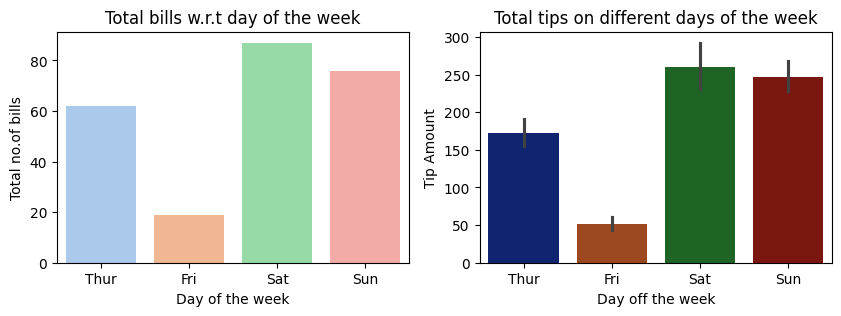

In [162]:
# To check no.of bills per day
plt.figure(figsize=[10,3])
plt.subplot(1,2,1)
day_count=tips['day'].value_counts()
sb.barplot(x=day_count.index,y=day_count.values,palette='pastel')
plt.xlabel('Day of the week')
plt.ylabel('Total no.of bills')
plt.title('Total bills w.r.t day of the week')

plt.subplot(1,2,2)
sb.barplot(data=tips,x='day',y='tip',estimator=np.sum,palette='dark')
plt.xlabel('Day off the week')
plt.ylabel('Tip Amount')
plt.title('Total tips on different days of the week')

### Total no.of on differentdays calc using numpy and python
print(tips.groupby('day')['total_bill'].count().sort_values(ascending=False))

### Total tips on differentdays calc using numpy and python
tips.groupby('day')['tip'].sum().sort_values(ascending=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_7188\2871437644.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=time_counts.index,y=time_counts.values,palette='bright')


Text(0.5, 1.0, 'Tips w.r.t time of the day')

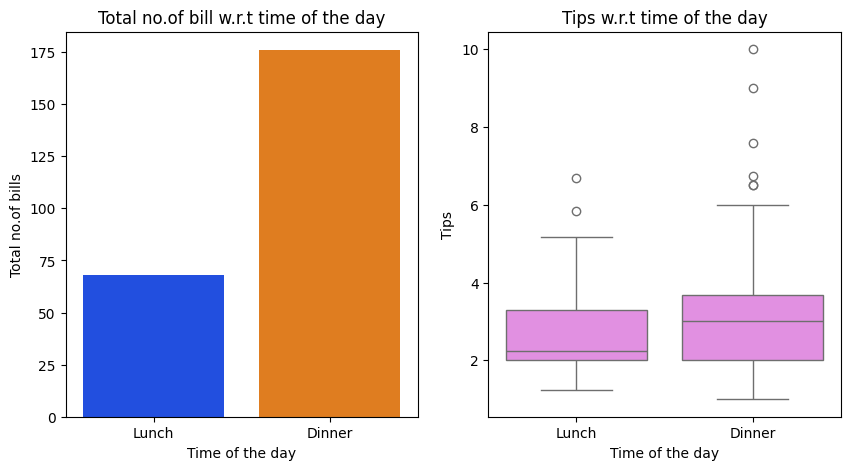

In [171]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
time_counts=tips['time'].value_counts()

## Time of the Day (Vs) Total bills
sb.barplot(x=time_counts.index,y=time_counts.values,palette='bright')
plt.xlabel('Time of the day')
plt.ylabel('Total no.of bills')
plt.title('Total no.of bill w.r.t time of the day')

## Time of the Day (Vs) Tips given
plt.subplot(1,2,2)
sb.boxplot(data=tips,x='time',y='tip',color='violet')
plt.xlabel('Time of the day')
plt.ylabel('Tips')
plt.title('Tips w.r.t time of the day')

C:\Users\HP\AppData\Local\Temp\ipykernel_7188\4284477837.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=size_counts.index,y=size_counts.values,palette='bright')


Text(0.5, 1.0, 'Tips w.r.t time of the day')

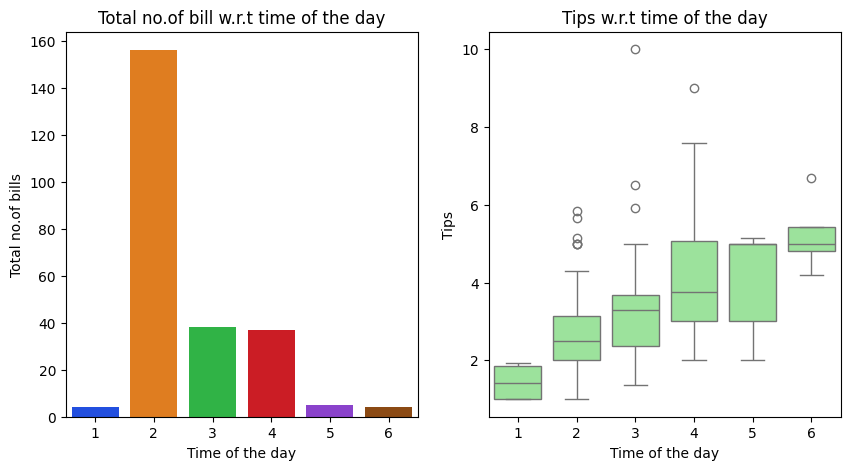

In [174]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
size_counts=tips['size'].value_counts()

## Party Size (Vs) Total bills
sb.barplot(x=size_counts.index,y=size_counts.values,palette='bright')
plt.xlabel('Time of the day')
plt.ylabel('Total no.of bills')
plt.title('Total no.of bill w.r.t time of the day')

## Party size (Vs) Tips given
plt.subplot(1,2,2)
sb.boxplot(data=tips,x='size',y='tip',color='lightgreen')
plt.xlabel('Time of the day')
plt.ylabel('Tips')
plt.title('Tips w.r.t time of the day')

Correlation between total bill and tips: 0.6757341092113641


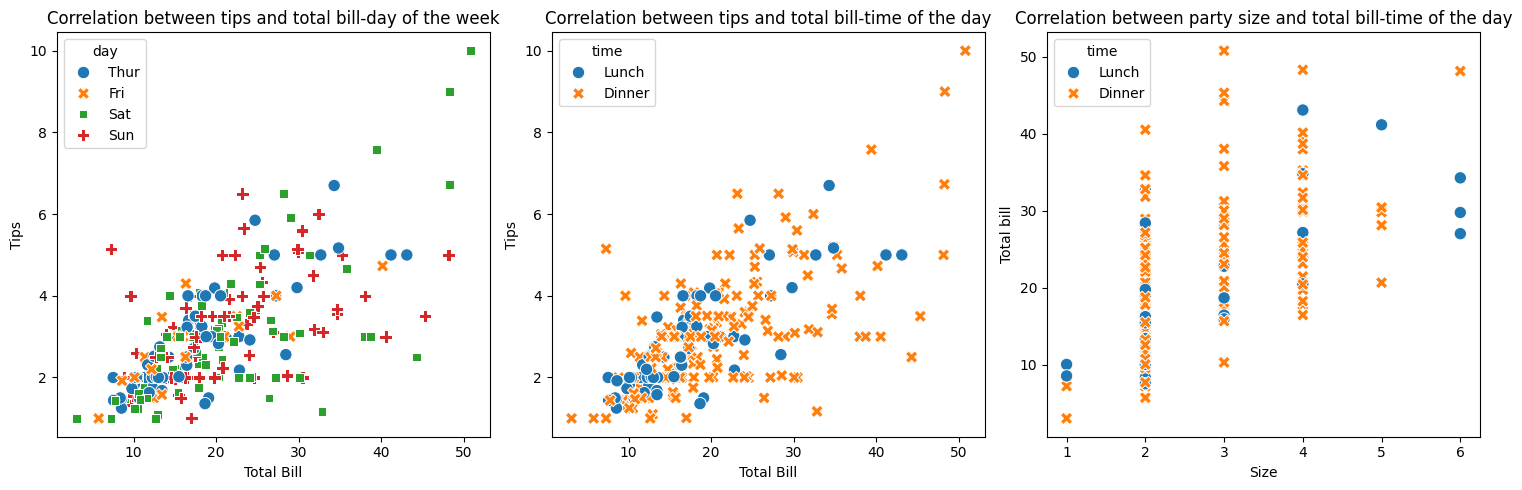

In [196]:
plt.figure(figsize=[15,5])

plt.subplot(1,3,1)
sb.scatterplot(data=tips,x='total_bill',y='tip',hue='day',style='day',s=80,alpha=1)
plt.xlabel('Total Bill')
plt.ylabel('Tips')
plt.title('Correlation between tips and total bill-day of the week')
plt.tight_layout()

print(f"Correlation between total bill and tips: {tips['total_bill'].corr(tips['tip'])}")

plt.subplot(1,3,2)
sb.scatterplot(data=tips,x='total_bill',y='tip',hue='time',style='time',s=80,alpha=1)
plt.xlabel('Total Bill')
plt.ylabel('Tips')
plt.title('Correlation between tips and total bill-time of the day')
plt.tight_layout()

plt.subplot(1,3,3)
sb.scatterplot(data=tips,x='size',y='total_bill',hue='time',style='time',s=80,alpha=1)
plt.xlabel('Size')
plt.ylabel('Total bill')
plt.title('Correlation between party size and total bill-time of the day')
plt.tight_layout()

   total_bill   tip     sex smoker  day    time  size  tip_perc
0       16.99  1.01  Female     No  Sun  Dinner     2      5.94
1       10.34  1.66    Male     No  Sun  Dinner     3     16.05
2       21.01  3.50    Male     No  Sun  Dinner     3     16.66
3       23.68  3.31    Male     No  Sun  Dinner     2     13.98
4       24.59  3.61  Female     No  Sun  Dinner     4     14.68
count    244.000000
mean      16.079754
std        6.107020
min        3.560000
25%       12.910000
50%       15.475000
75%       19.147500
max       71.030000
Name: tip_perc, dtype: float64


Text(0, 0.5, 'Tip Percentage')

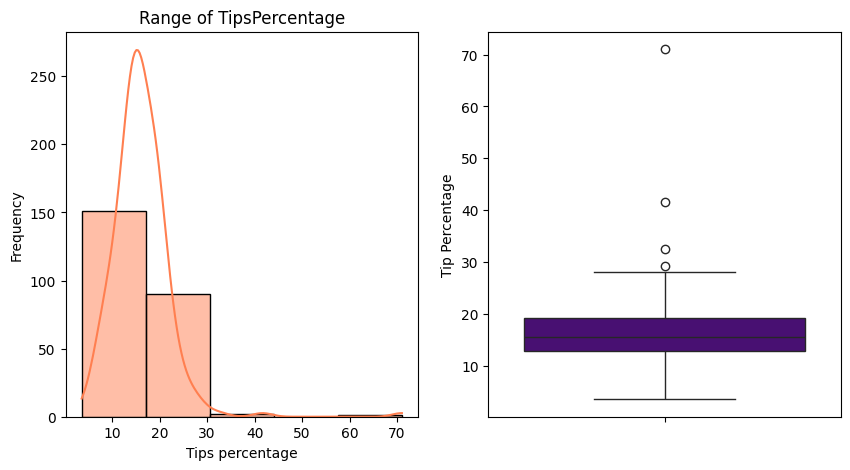

In [214]:
#Derieving Percentage of Tips
plt.figure(figsize=(10,5))
tips['tip_perc']=round((tips['tip']/tips['total_bill'])*100, 2)
print(tips.head())
print(tips['tip_perc'].describe())
plt.subplot(1,2,1)
sb.histplot(tips['tip_perc'],bins=5,color='coral',kde=True)
plt.xlabel('Tips percentage')
plt.ylabel('Frequency')
plt.title('Range of TipsPercentage')

plt.subplot(1,2,2)
sb.boxplot(y=tips['tip_perc'],color='indigo')
plt.ylabel('Tip Percentage')


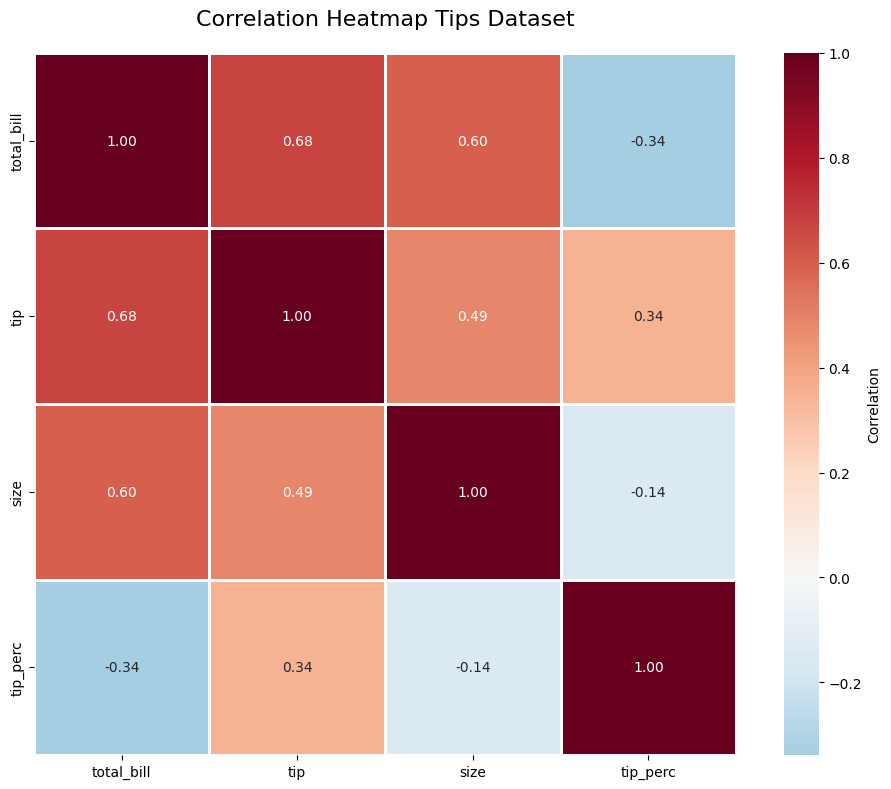


key Correlations:
total_bill   vs tip         :  0.676
total_bill   vs size        :  0.598
total_bill   vs tip_perc    : -0.339
tip          vs size        :  0.489
tip          vs tip_perc    :  0.342
size         vs tip_perc    : -0.143


In [230]:
#Select numerical colυπης
numerical_cols = ['total_bill', 'tip', 'size', 'tip_perc']
correlation_matrix = tips [numerical_cols].corr()
#Create heatmap
plt.figure(figsize=(10, 8))
sb.heatmap(correlation_matrix, annot=True, fmt='.2f',cmap='RdBu_r', center=0, square=True,
linewidths=2, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap Tips Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
print("\nkey Correlations:")
print("="*50)
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        corr_val=correlation_matrix.iloc[i, j]
        print(f"{numerical_cols[i]:12} vs {numerical_cols[j]:12}: {corr_val:6.3f}")